In [1]:
!pip install rdkit

started
Index(['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumHeteroatoms'], dtype='object')
Total descriptors used:           MolWt  HeavyAtomMolWt  ExactMolWt  NumHeteroatoms
0        16.043          12.011   16.031300               0
1        17.031          14.007   17.026549               1
2        18.015          15.999   18.010565               1
3        26.038          24.022   26.015650               0
4        27.026          26.018   27.010899               1
...         ...             ...         ...             ...
133880  121.139         114.083  121.052764               2
133881  121.139         114.083  121.052764               2
133882  120.155         112.091  120.068748               2
133883  119.167         110.095  119.073499               1
133884  121.139         114.083  121.052764               2

[133885 rows x 4 columns]
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Fixed 

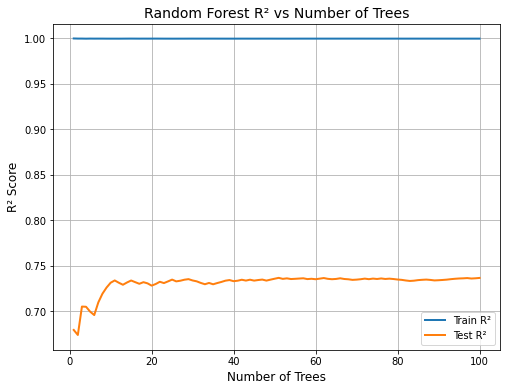


Results
----------------------------------------
Train MSE : 0.1228
Train R²  : 0.9998
Train RMSE : 0.3504
Test MSE  : 1525.2569
Test R²   : 0.7367
Test RMSE : 39.0545
Number of trees used= 100


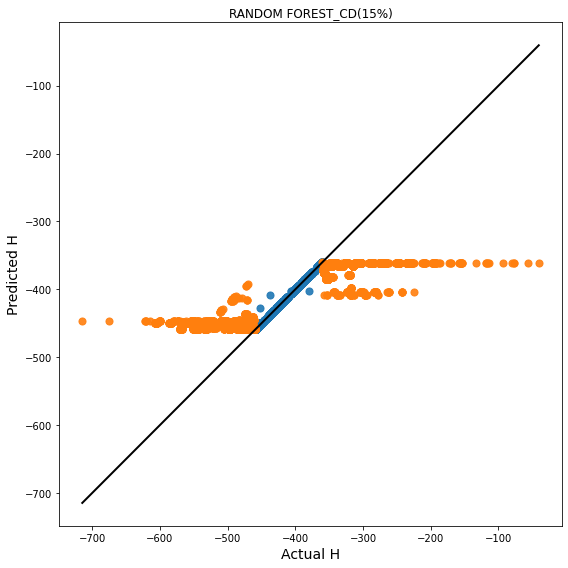

Best Tree = 51
Best Tree R2 = 0.7367431859713842

Training Fraction = 30%
Training Samples = 32704


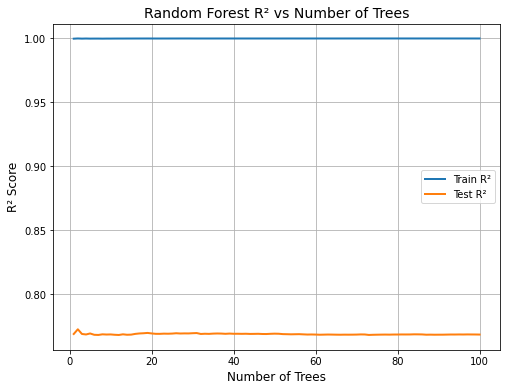


Results
----------------------------------------
Train MSE : 0.0501
Train R²  : 0.9999
Train RMSE : 0.2239
Test MSE  : 1340.4410
Test R²   : 0.7686
Test RMSE : 36.6120
Number of trees used= 100


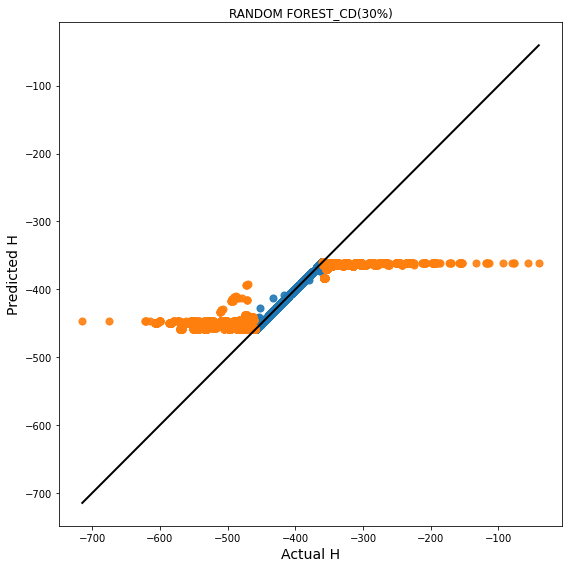

Best Tree = 2
Best Tree R2 = 0.7726774482246782

Training Fraction = 45%
Training Samples = 49057


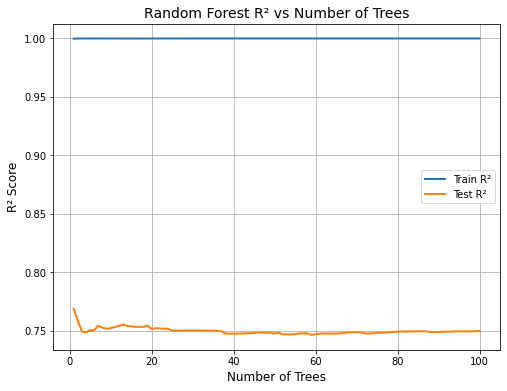


Results
----------------------------------------
Train MSE : 0.0259
Train R²  : 1.0000
Train RMSE : 0.1609
Test MSE  : 1450.0007
Test R²   : 0.7497
Test RMSE : 38.0789
Number of trees used= 100


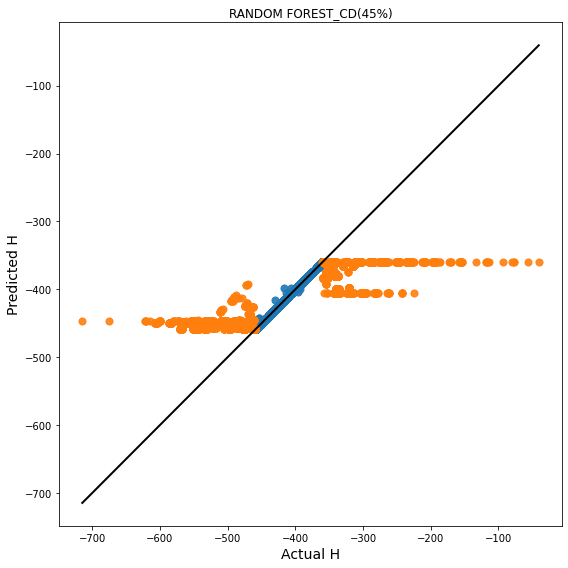

Best Tree = 1
Best Tree R2 = 0.7687702968180878

Training Fraction = 60%
Training Samples = 65409


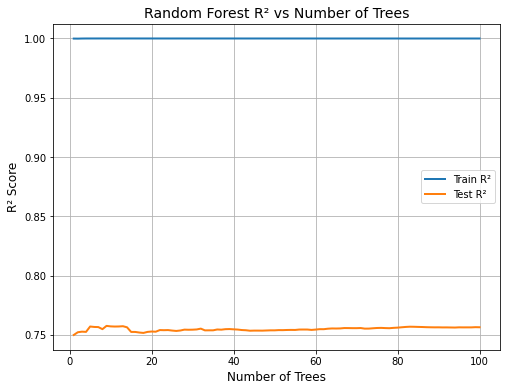


Results
----------------------------------------
Train MSE : 0.0505
Train R²  : 0.9999
Train RMSE : 0.2248
Test MSE  : 1410.6942
Test R²   : 0.7564
Test RMSE : 37.5592
Number of trees used= 100


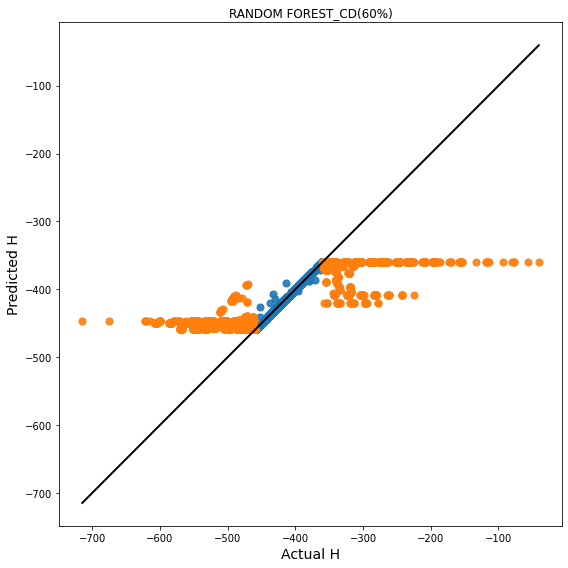

Best Tree = 9
Best Tree R2 = 0.7576046291349162

Training Fraction = 75%
Training Samples = 81762


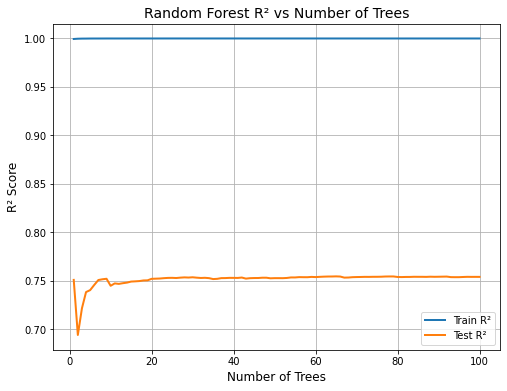


Results
----------------------------------------
Train MSE : 0.0401
Train R²  : 0.9999
Train RMSE : 0.2002
Test MSE  : 1425.5346
Test R²   : 0.7539
Test RMSE : 37.7563
Number of trees used= 100


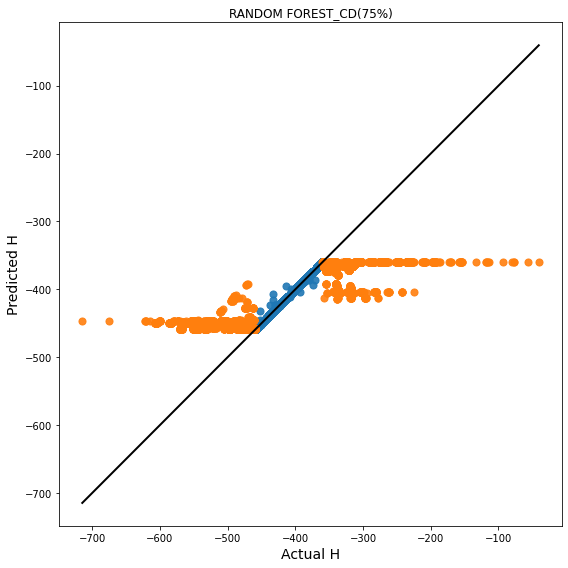

Best Tree = 65
Best Tree R2 = 0.7543958340901381

Training Fraction = 90%
Training Samples = 98114


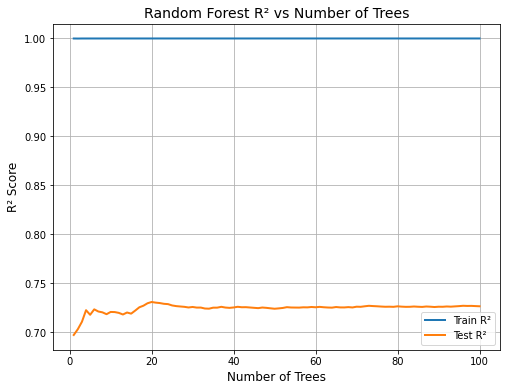


Results
----------------------------------------
Train MSE : 0.0270
Train R²  : 1.0000
Train RMSE : 0.1643
Test MSE  : 1584.2307
Test R²   : 0.7265
Test RMSE : 39.8024
Number of trees used= 100


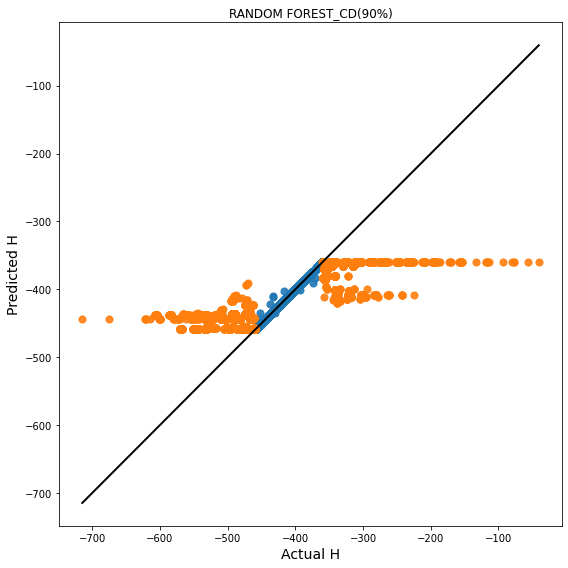

Best Tree = 20
Best Tree R2 = 0.7308382105110001


In [9]:
###########################################################
# CHEMICAL DESCRIPTOR
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
X_df = pd.read_csv("selected_descriptors.csv")
X_df = X_df.drop(columns=["SMILES"])

print("started")

#==========================================
#CHEMICAL DESCRIPTOR WITH SELECTED FEATURES
#==========================================
y = data["H"].values

print(X_df.columns)
print("Total descriptors used:",X_df)

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X_df[train_mask]
y_train_full = y[train_mask]

X_test_all = X_df[test_mask]
y_test_all = y[test_mask]

print("Training range:", y_train_full.min(), "to", y_train_full.max())
print("Testing range:", y_test_all.min(), "to", y_test_all.max())

print("Training samples:", len(X_train_full))
print("Testing samples:", len(X_test_all))

#=================================
#FIX TEST SET TO 24869 SAMPLES
#==================================
np.random.seed(42)

test_indices = np.random.choice(len(X_test_all),size=24869,replace=False)

X_test = X_test_all.iloc[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Sample:",len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )
    X_train_sub = X_train_full.iloc[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    X_train_scaled = X_train_sub
    X_test_scaled = X_test

    # ===============================
    # RANDOM FOREST REGRESSION
    # ===============================
    
    rf = RandomForestRegressor(
        n_estimators=1,
        random_state=42,
        warm_start=True,
        n_jobs=-1
    )

    train_r2_list = []
    test_r2_list = []

    for n_trees in range(1, 101):

        rf.set_params(n_estimators=n_trees)
        rf.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = rf.predict(X_train_scaled)
        y_pred_test_iter = rf.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    #=============================
    #PLOT OF R2 VS NUMBER OF TRESS
    #==============================

    plt.figure(figsize=(8,6))

    plt.plot(range(1,101),
             train_r2_list,
             label='Train R²',
             linewidth=2)
    
    plt.plot(range(1,101),
             test_r2_list,
             label='Test R²',
             linewidth=2)

    plt.xlabel('Number of Trees', fontsize=12)   
    plt.ylabel('R² Score', fontsize=12)
    plt.title('Random Forest R² vs Number of Trees', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.savefig(
    f"RF_R2__CD_Curve_{int(frac*100)}.png", dpi=600, bbox_inches='tight')
    plt.show()
    
    y_pred_train = rf.predict(X_train_scaled)
    y_pred_test = rf.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE : {rmse_test:.4f}")

    rf.n_estimators
    print("Number of trees used=",rf.n_estimators)
    
    #=================================
    #PARITY PLOT
    #===============================
    plt.figure(figsize=(8,8))

    scatter = plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )

    scatter = plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

    plt.xlabel('Actual H', fontsize=14)
    plt.ylabel('Predicted H', fontsize=14)
    plt.title(f'RANDOM FOREST_CD({int(frac*100)}%)')
    plt.tight_layout()
    plt.savefig(f"CD_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')

    plt.show()
    
    #=========================
    #BEST TREE
    #==========================
    best_tree = np.argmax(test_r2_list)+1
    best_r2 = max(test_r2_list)
    print("Best Tree =", best_tree)
    print("Best Tree R2 =",best_r2)

Total RDKIT descriptors: 209
started
success
Training range: -459.185274 to -360.000294
Testing range: -714.559209 to -40.475117
Training samples: 109016
Testing samples: 24869
Fixed Test Sample: 24869

Training Fraction = 15%
Training Samples = 16352


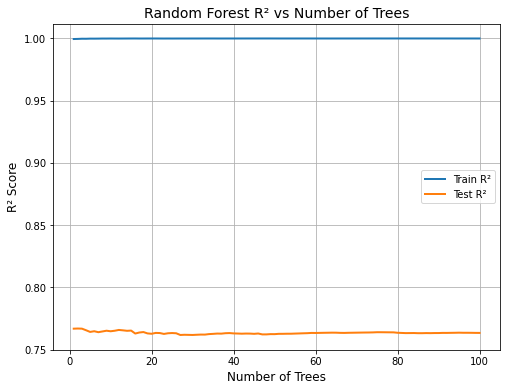


Results
----------------------------------------
Train MSE : 0.0705
Train R²  : 0.9999
Train RMSE : 0.2655
Test MSE  : 1370.6171
Test R²   : 0.7634
Test RMSE : 37.0218
Number of trees used= 100


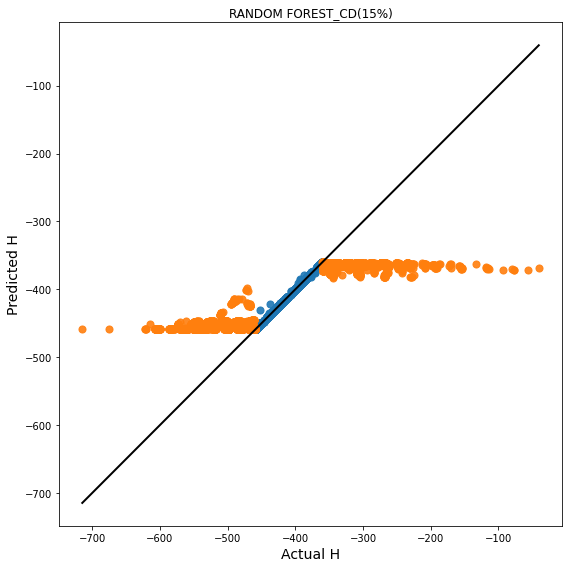

Best Tree = 2
Best Tree R2 = 0.7668776318642518

Training Fraction = 30%
Training Samples = 32704


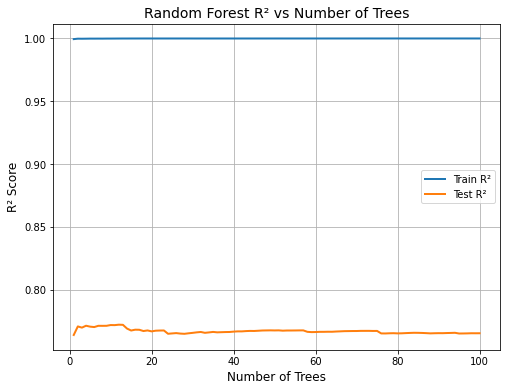


Results
----------------------------------------
Train MSE : 0.0399
Train R²  : 0.9999
Train RMSE : 0.1998
Test MSE  : 1360.0630
Test R²   : 0.7652
Test RMSE : 36.8790
Number of trees used= 100


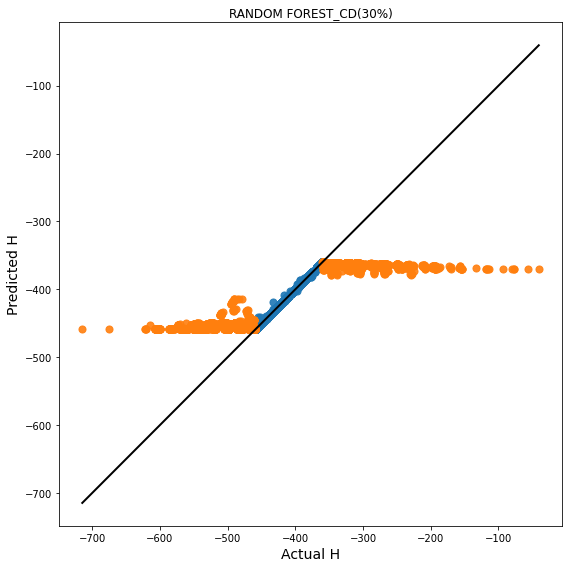

Best Tree = 12
Best Tree R2 = 0.7719949548680807

Training Fraction = 45%
Training Samples = 49057


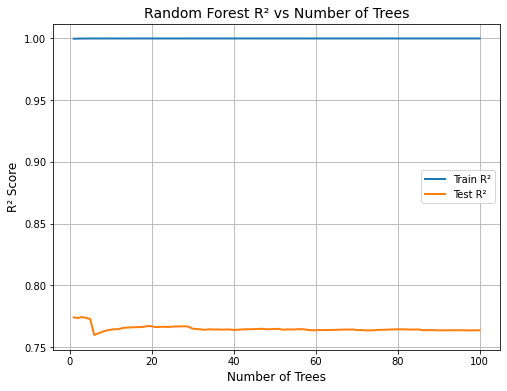


Results
----------------------------------------
Train MSE : 0.0227
Train R²  : 1.0000
Train RMSE : 0.1506
Test MSE  : 1369.0001
Test R²   : 0.7636
Test RMSE : 37.0000
Number of trees used= 100


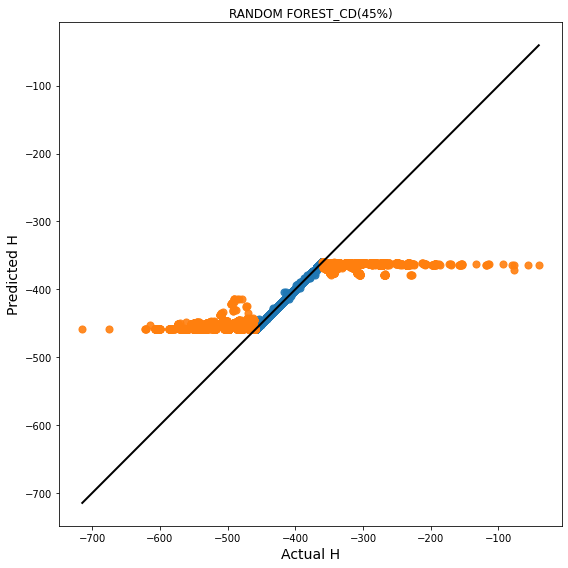

Best Tree = 3
Best Tree R2 = 0.7742781218600044

Training Fraction = 60%
Training Samples = 65409


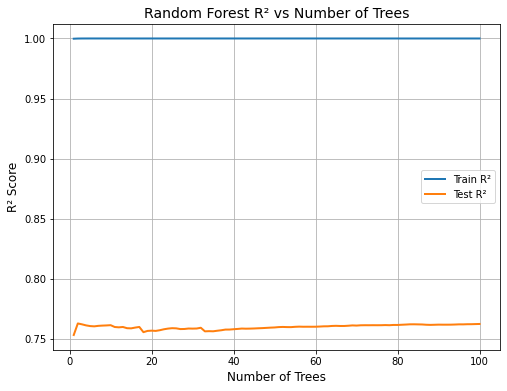


Results
----------------------------------------
Train MSE : 0.0224
Train R²  : 1.0000
Train RMSE : 0.1495
Test MSE  : 1375.9379
Test R²   : 0.7624
Test RMSE : 37.0936
Number of trees used= 100


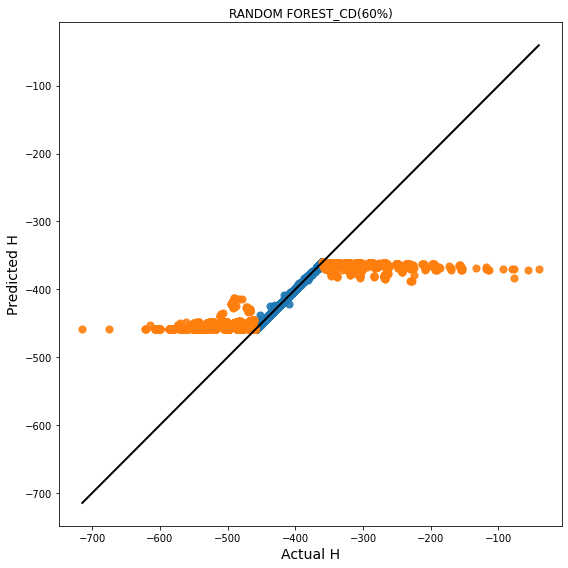

Best Tree = 2
Best Tree R2 = 0.7628672419557744

Training Fraction = 75%
Training Samples = 81762


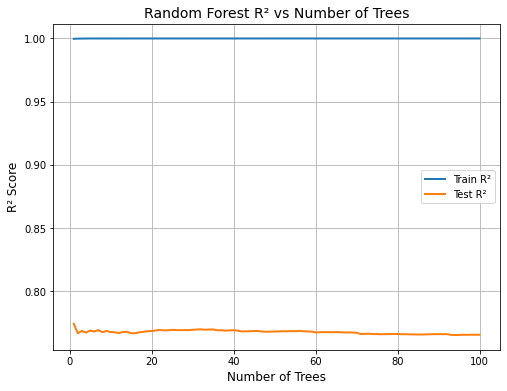


Results
----------------------------------------
Train MSE : 0.0147
Train R²  : 1.0000
Train RMSE : 0.1214
Test MSE  : 1356.8660
Test R²   : 0.7657
Test RMSE : 36.8357
Number of trees used= 100


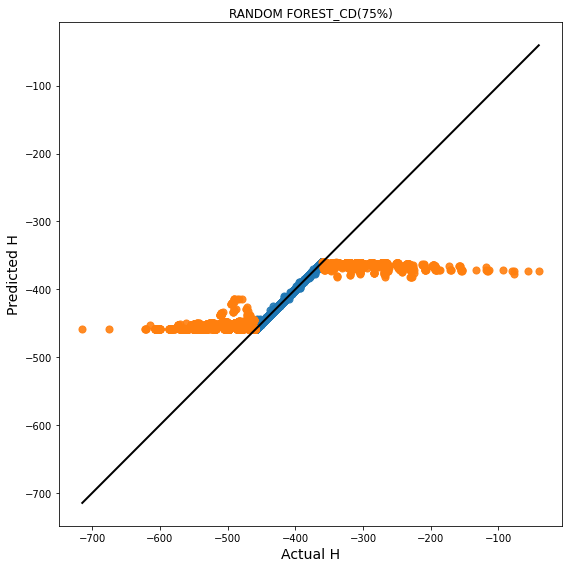

Best Tree = 1
Best Tree R2 = 0.7744284833858205

Training Fraction = 90%
Training Samples = 98114


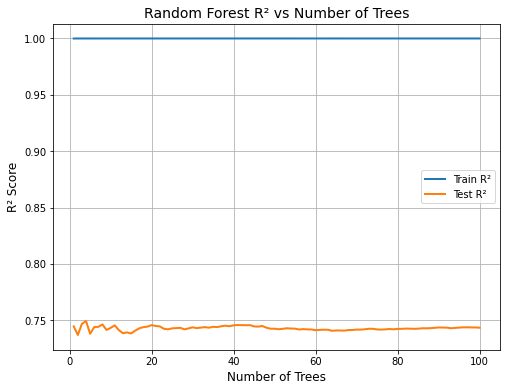


Results
----------------------------------------
Train MSE : 0.0099
Train R²  : 1.0000
Train RMSE : 0.0994
Test MSE  : 1486.4894
Test R²   : 0.7434
Test RMSE : 38.5550
Number of trees used= 100


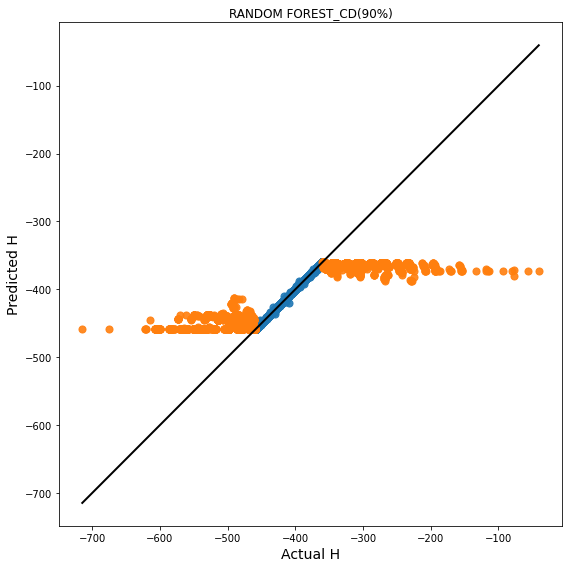

Best Tree = 4
Best Tree R2 = 0.7492276307172379


In [10]:
###########################################################
# CHEMICAL DESCRIPTOR
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Descriptors

descriptor_names = [name for name,func in Descriptors.descList]
print("Total RDKIT descriptors:", len(Descriptors.descList))

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"]
y = data["H"].values
print("started")

#==========================================
#CHEMICAL DESCRIPTOR WITHOUT SELECTED FEATURES
#==========================================

descriptor_values = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        values = [func(mol) for name,func in Descriptors.descList]
    else:
        values = [np.nan]*len(descriptor_name)
    
    descriptor_values.append(values)
    
X_df = pd.DataFrame(descriptor_values, columns=descriptor_names)
print("success")
# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X_df[train_mask]
y_train_full = y[train_mask]

X_test_all = X_df[test_mask]
y_test_all = y[test_mask]

print("Training range:", y_train_full.min(), "to", y_train_full.max())
print("Testing range:", y_test_all.min(), "to", y_test_all.max())

print("Training samples:", len(X_train_full))
print("Testing samples:", len(X_test_all))

#=================================
#FIX TEST SET TO 24869 SAMPLES
#==================================
np.random.seed(42)

test_indices = np.random.choice(len(X_test_all),size=24869,replace=False)

X_test = X_test_all.iloc[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Sample:",len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )
    X_train_sub = X_train_full.iloc[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    X_train_scaled = X_train_sub
    X_test_scaled = X_test

    # ===============================
    # RANDOM FOREST REGRESSION
    # ===============================
    
    rf = RandomForestRegressor(
        n_estimators=1,
        random_state=42,
        warm_start=True,
        n_jobs=-1
    )

    train_r2_list = []
    test_r2_list = []

    for n_trees in range(1, 101):

        rf.set_params(n_estimators=n_trees)
        rf.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = rf.predict(X_train_scaled)
        y_pred_test_iter = rf.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    #=============================
    #PLOT OF R2 VS NUMBER OF TRESS
    #==============================

    plt.figure(figsize=(8,6))

    plt.plot(range(1,101),
             train_r2_list,
             label='Train R²',
             linewidth=2)
    
    plt.plot(range(1,101),
             test_r2_list,
             label='Test R²',
             linewidth=2)

    plt.xlabel('Number of Trees', fontsize=12)   
    plt.ylabel('R² Score', fontsize=12)
    plt.title('Random Forest R² vs Number of Trees', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.savefig(
    f"RF_R2__CD_Curve_{int(frac*100)}.png", dpi=600, bbox_inches='tight')
    plt.show()
    
    y_pred_train = rf.predict(X_train_scaled)
    y_pred_test = rf.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE : {rmse_test:.4f}")

    rf.n_estimators
    print("Number of trees used=",rf.n_estimators)
    
    #=================================
    #PARITY PLOT
    #===============================
    plt.figure(figsize=(8,8))

    scatter = plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )

    scatter = plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

    plt.xlabel('Actual H', fontsize=14)
    plt.ylabel('Predicted H', fontsize=14)
    plt.title(f'RANDOM FOREST_CD({int(frac*100)}%)')
    plt.tight_layout()
    plt.savefig(f"CD_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')

    plt.show()
    
    #=========================
    #BEST TREE
    #==========================
    best_tree = np.argmax(test_r2_list)+1
    best_r2 = max(test_r2_list)
    print("Best Tree =", best_tree)
    print("Best Tree R2 =",best_r2)